##### Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

##### Load the datasets

In [2]:
general_a = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\General_Medicine_Ward_A_TimeSeries.csv")


In [3]:
general_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hospital_id     3655 non-null   object 
 1   datetime        3655 non-null   object 
 2   ward            3655 non-null   object 
 3   occupied_beds   3655 non-null   float64
 4   staffed_beds    3655 non-null   float64
 5   occupancy_rate  3655 non-null   float64
dtypes: float64(3), object(3)
memory usage: 171.5+ KB


- Run the ADF test for every hospital

In [4]:
general_a["hospital_id"].unique()

array(['HHN-BIR-01', 'HHN-EDI-01', 'HHN-LON-01', 'HHN-LON-02',
       'HHN-MAN-01'], dtype=object)

In [5]:
results = []

for hospital in general_a["hospital_id"].unique():
    hospital_data = (general_a[general_a["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    adf = adfuller(hospital_data["occupied_beds"])
    results.append({"Hospital": hospital, "ADF Statistic": round(adf[0],4), "p-value": round(adf[1],4), 
                    "Stationary": "Yes" if adf[1] < 0.05 else "No"})

adf_results = pd.DataFrame(results)

print(f"ADF Test Results for General Medicine Ward A Unit Occupied Beds")
adf_results

ADF Test Results for General Medicine Ward A Unit Occupied Beds


,Hospital,ADF Statistic,p-value,Stationary
0,HHN-BIR-01,-7.0066,0.0000,Yes
1,HHN-EDI-01,-3.4961,0.0081,Yes
2,HHN-LON-01,-2.7177,0.0710,No
3,HHN-LON-02,-6.5842,0.0000,Yes
4,HHN-MAN-01,-6.9128,0.0000,Yes


      Four hospitals (Birmingham, Edinburgh, London 2, and Manchester) showed stable bed occupancy, meaning demand stayed around a normal level over time.
      London 1 was the only hospital that was not stable, showing a changing trend in bed occupancy over time.
      The increasing or decreasing trend at London 1 may be caused by higher patient demand, seasonal illnesses, or delayed patient discharges.
      Because London 1 behaves differently, one forecasting model cannot be used for all hospitals.
      The four stable hospitals can use a SARIMA model with d = 0 (no differencing).
      London 1 requires d = 1 (first differencing) to remove the trend before forecasting.
      These results show that forecasting models should be tailored to each hospital to improve prediction accuracy.

- Autocorrelation (ACF) for all hospitals

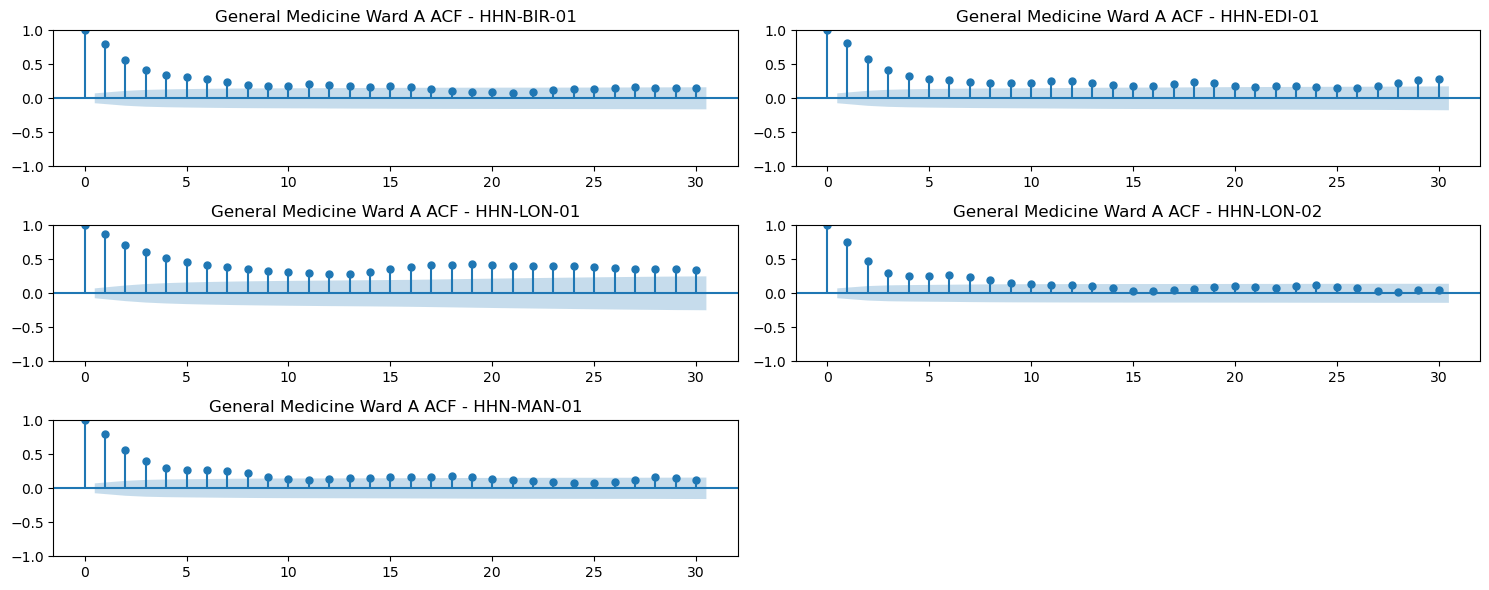

In [6]:
# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
axes = axes.flatten()

# Loop through hospitals
for i, hospital in enumerate(sorted(general_a["hospital_id"].unique())):

    hospital_data = (general_a[general_a["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_acf(hospital_data["occupied_beds"], lags=30,ax=axes[i])
    axes[i].set_title(f"General Medicine Ward A ACF - {hospital}")

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

     London 1 was different from the other hospitals, showing a very strong and long-lasting occupancy pattern that did not reduce over time.
     This confirms that London 1 is not stationary and requires differencing (d = 1) before forecasting.
     Birmingham, Edinburgh, London 2, and Manchester showed normal memory decay, meaning occupancy returned to normal over time and the data remained stable.
     All hospitals showed weekly patterns in bed occupancy, likely caused by weekday admissions and weekend discharge delays.
     The results suggest using different forecasting models:
     London 1: SARIMA/ARIMA with d = 1.
     Other hospitals: SARIMA/ARIMA with d = 0.
     Overall, the analysis shows that London 1 needs a separate forecasting approach, while the other hospitals can be modelled using the standard method.

- PACF for all hospitals

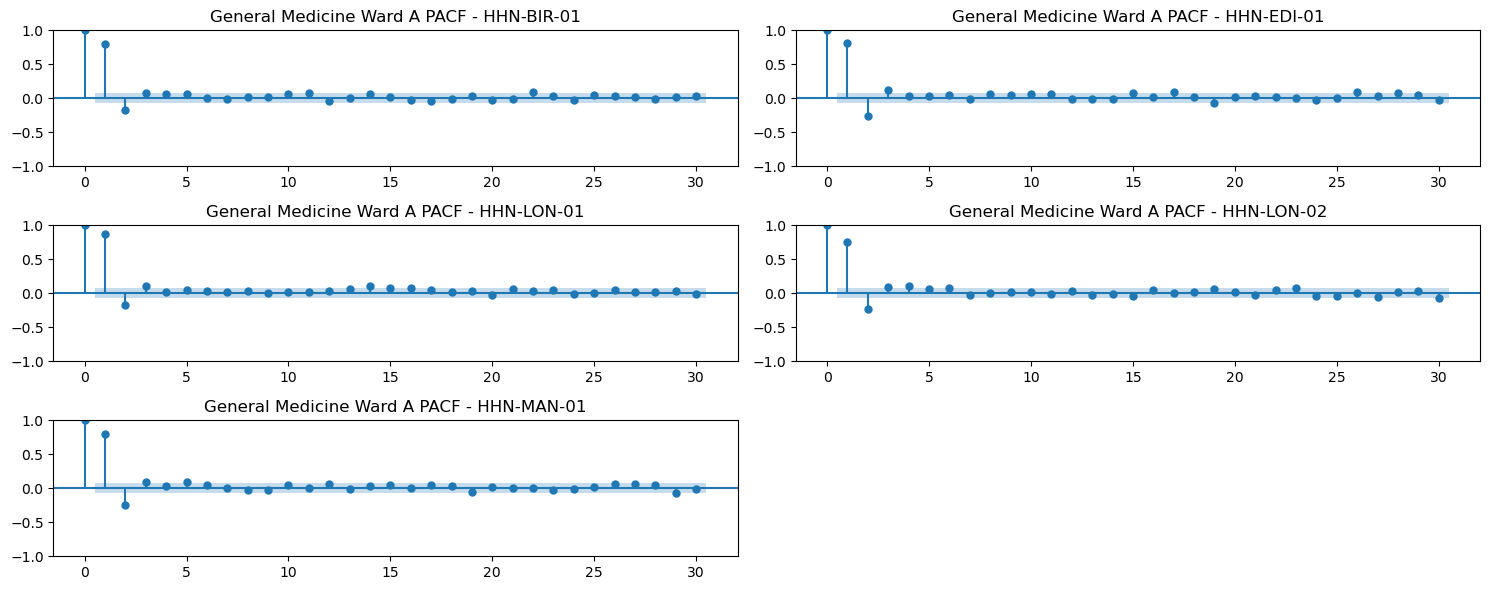

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
axes = axes.flatten()

for i, hospital in enumerate(sorted(general_a["hospital_id"].unique())):

    hospital_data = (general_a[general_a["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_pacf(hospital_data["occupied_beds"], lags=30, ax=axes[i], method="ywm")
    axes[i].set_title(f"General Medicine Ward A PACF - {hospital}")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

     All five hospitals showed a similar 2-day occupancy pattern.
     Yesterday's bed occupancy (Lag 1) had the strongest influence on today's occupancy.
     Occupancy from two days ago (Lag 2) had a negative effect, showing that many patients are discharged within 24–48 hours.
     After the first two days, earlier occupancy had very little effect on predicting future demand.
     The results show that a 2-day memory is enough to model General Medicine bed occupancy.
     London 1 still requires differencing because its occupancy shows a long-term trend.
     The other four hospitals can be modelled without differencing because their occupancy is already stable.

- Seasonal Decomposition for all hospitals

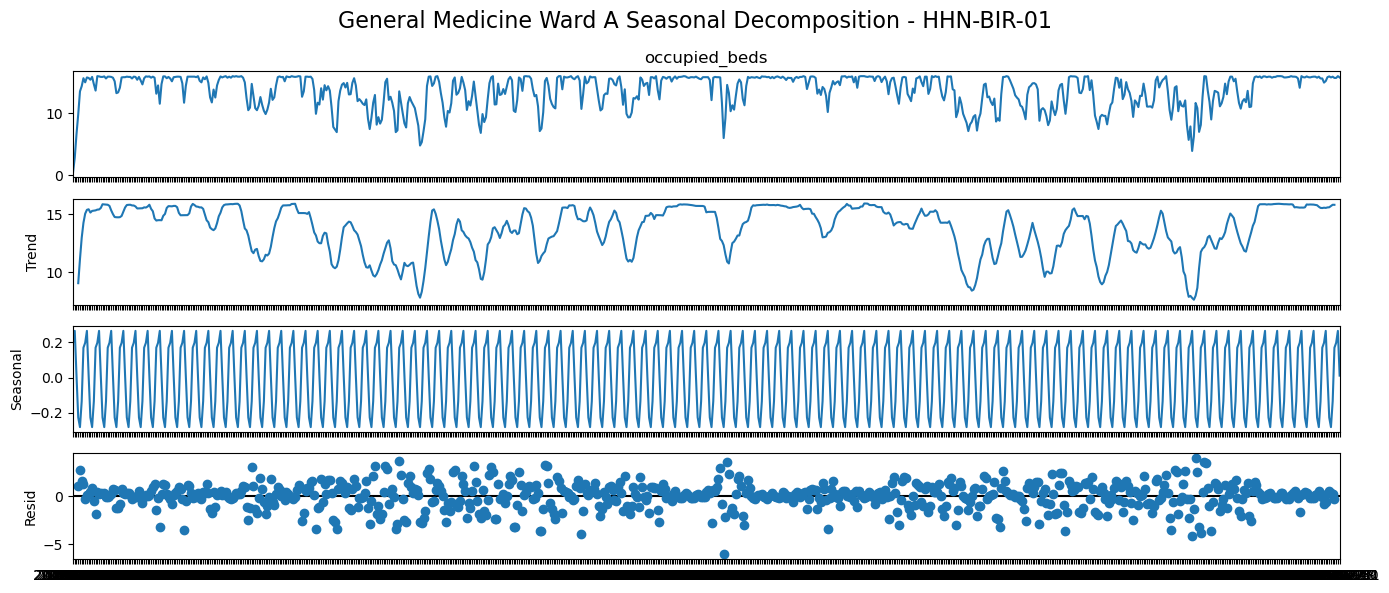

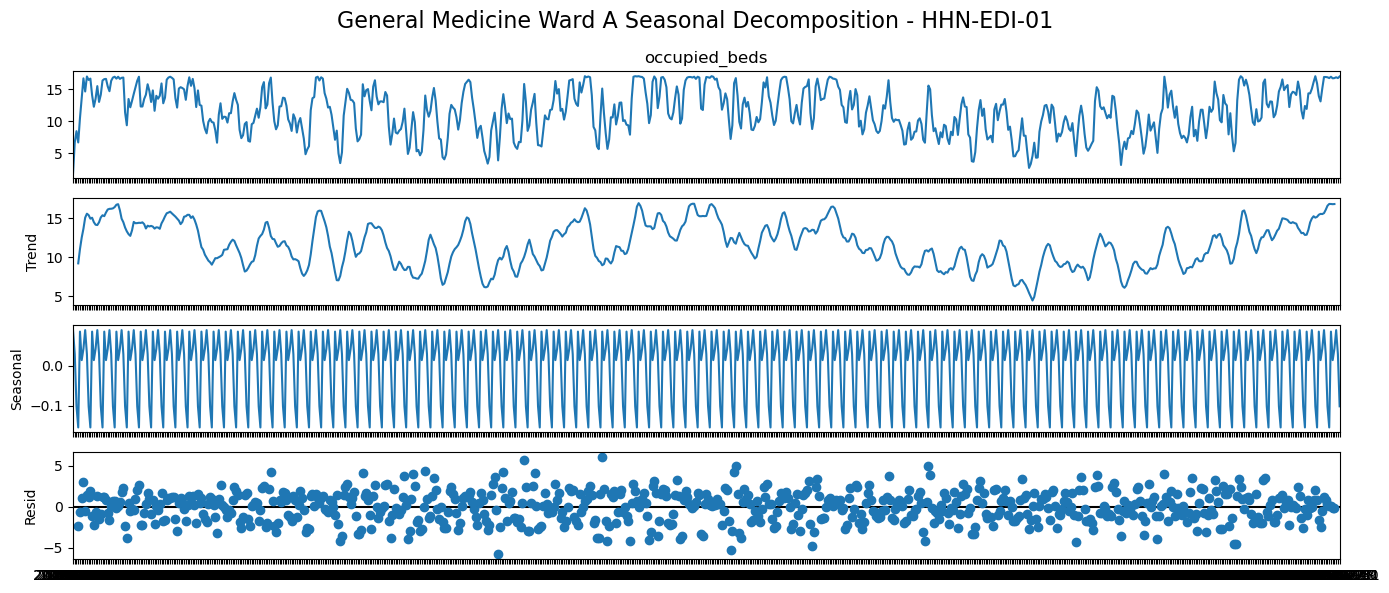

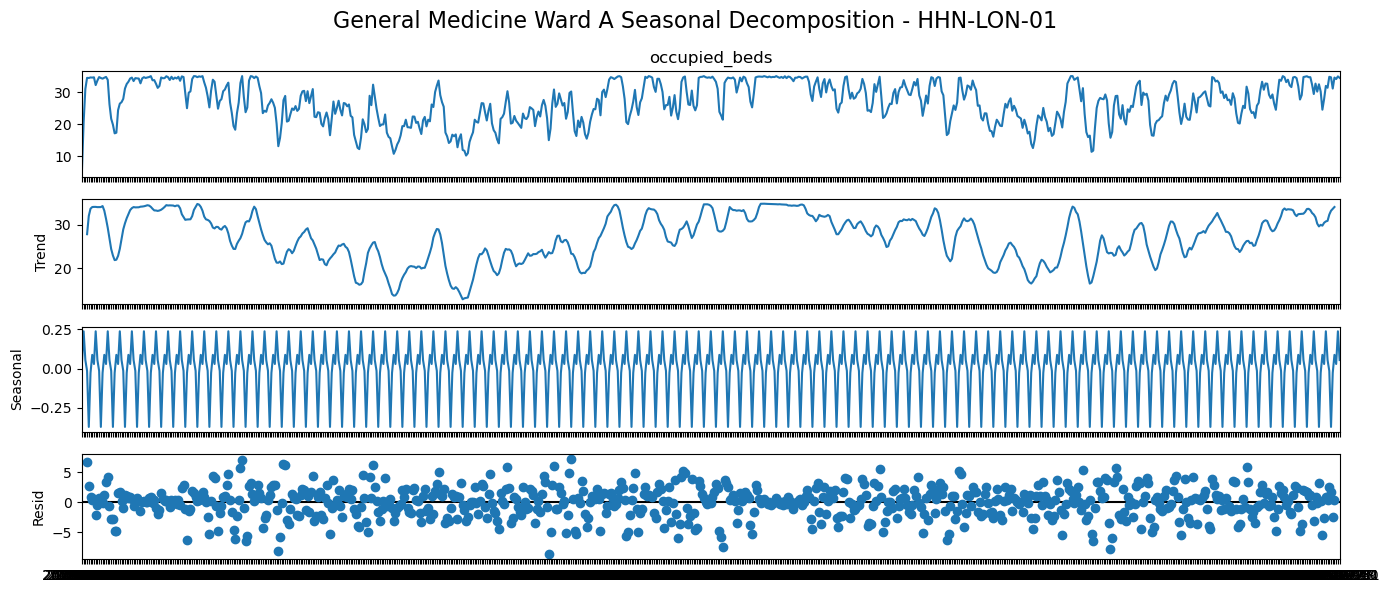

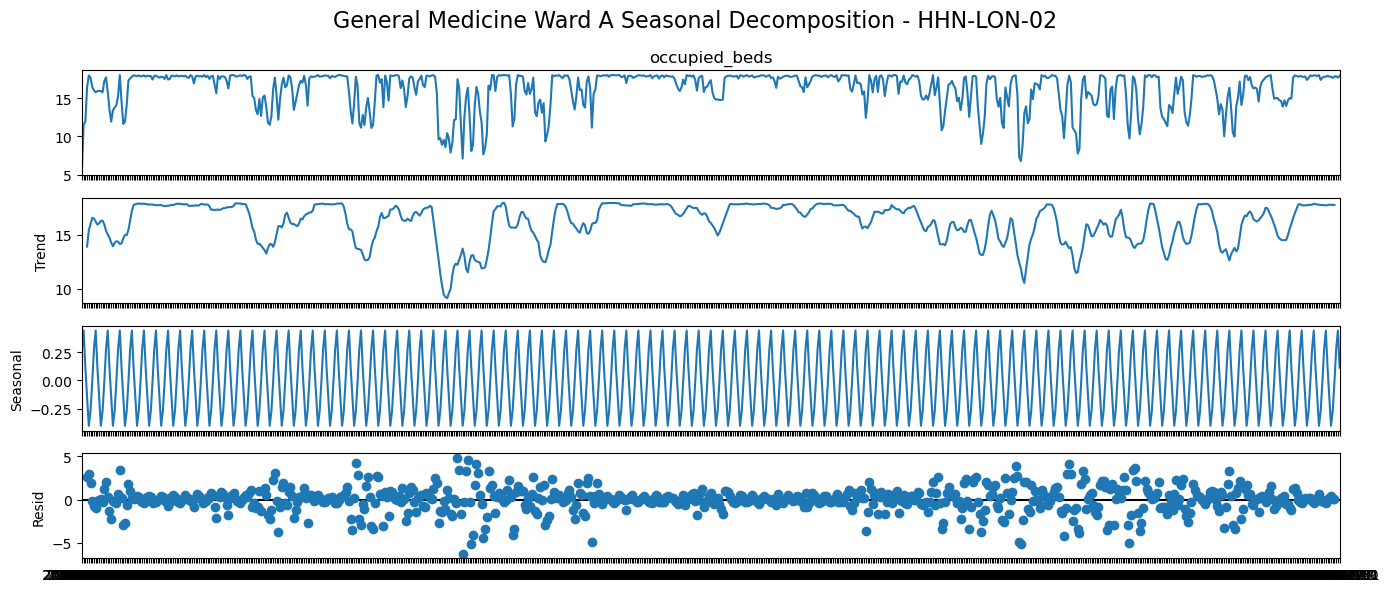

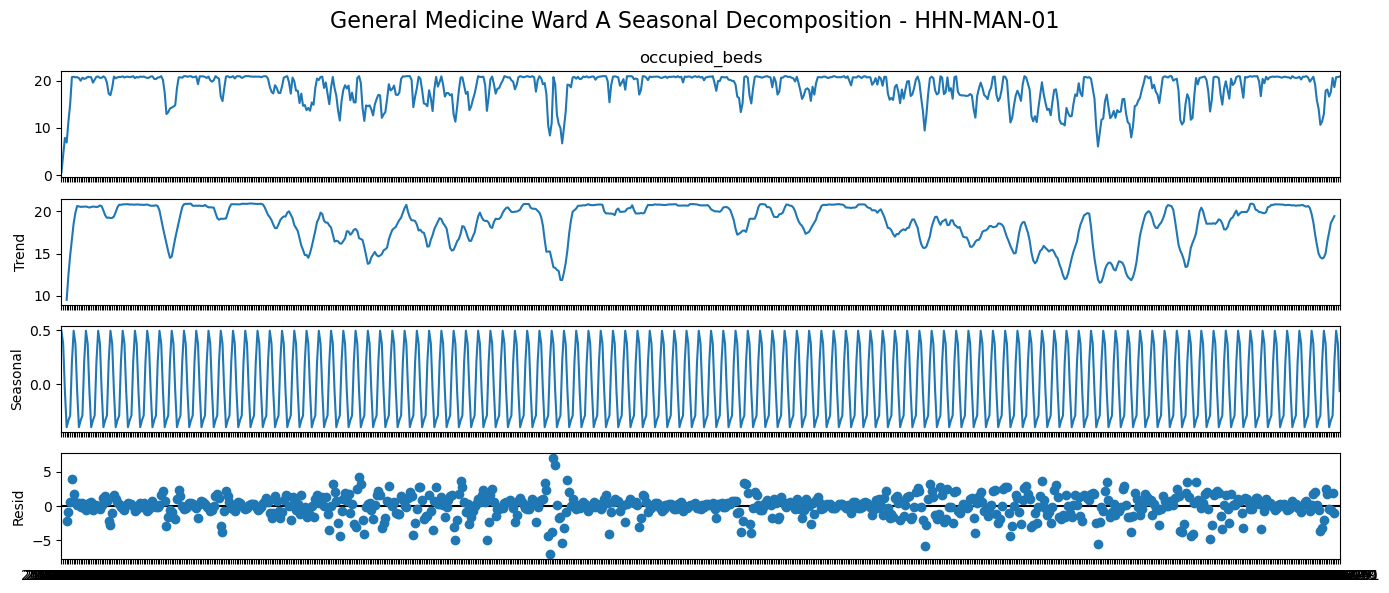

In [8]:
for hospital in sorted(general_a["hospital_id"].unique()):

    hospital_data = (general_a[general_a["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    fig = result.plot()
    fig.set_size_inches(14,6)
    fig.suptitle(f"General Medicine Ward A Seasonal Decomposition - {hospital}", fontsize=16)
    plt.tight_layout()
    plt.show()

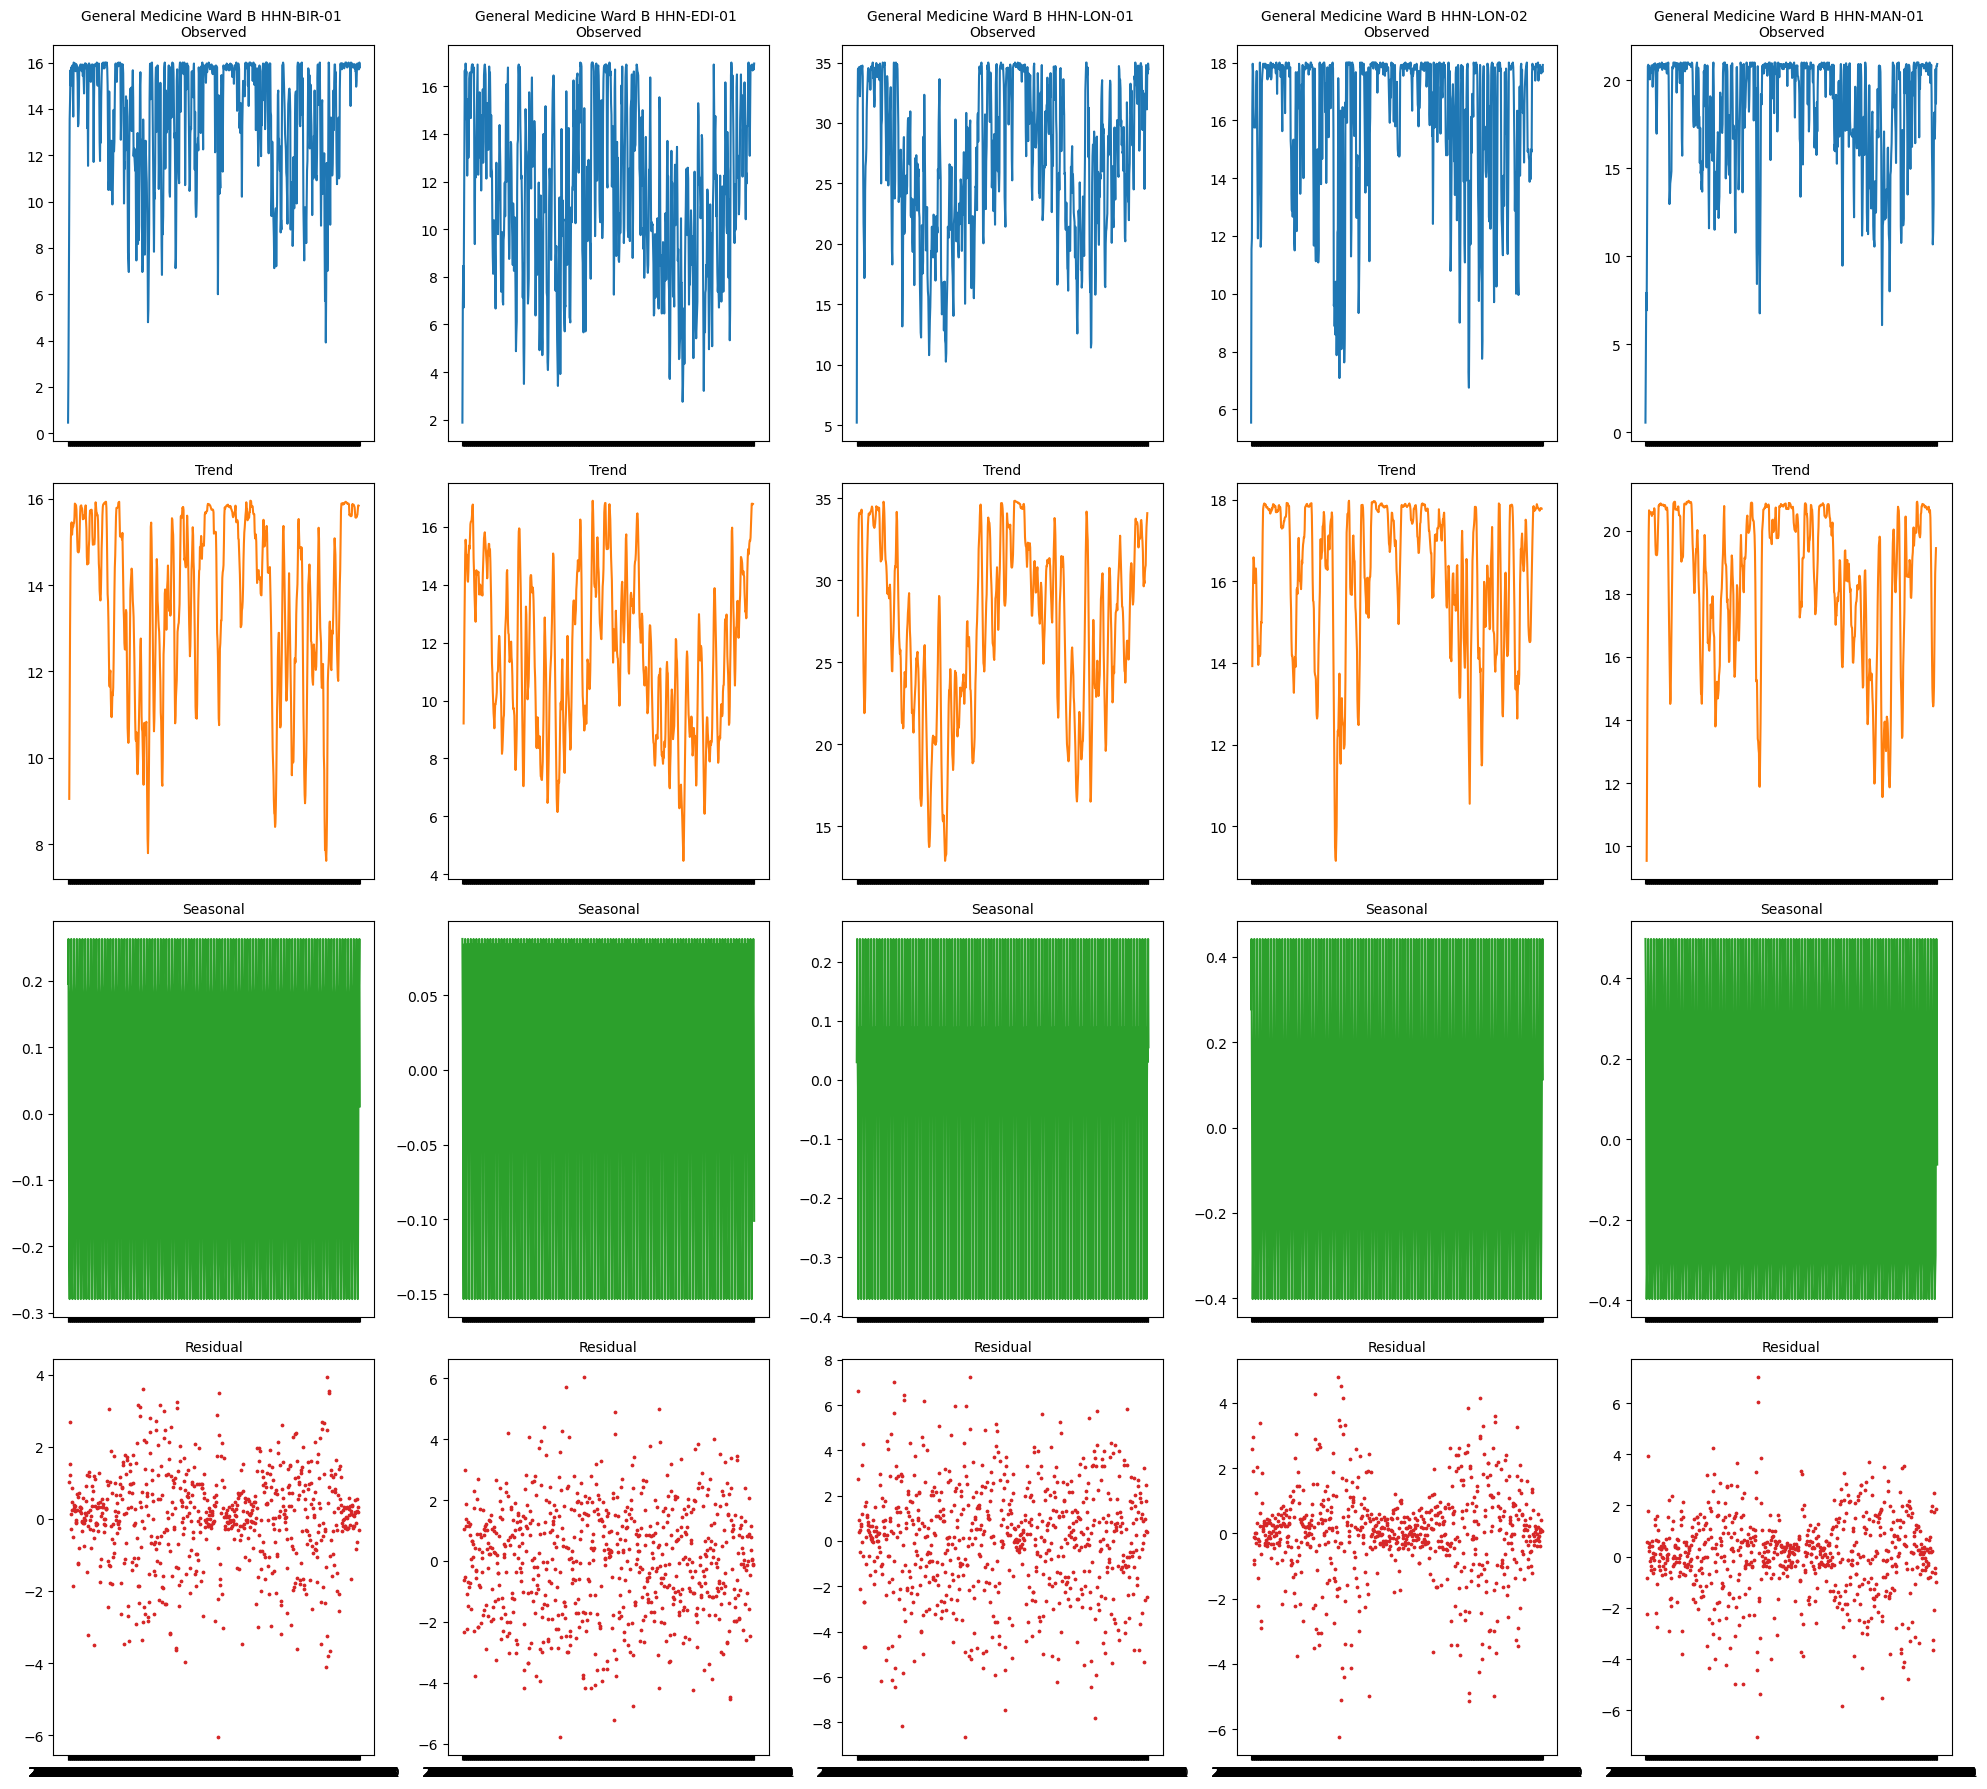

In [10]:
# Create a grid: 4 rows (Observed/Trend/Season/Resid) by X columns (one per hospital)
fig, axes = plt.subplots(4, 5, figsize=(20, 18), sharex=True)

hospitals = sorted(general_a["hospital_id"].unique())
for col_idx, hospital in enumerate(hospitals):
    # Filter and decompose data
    hospital_data = general_a[general_a["hospital_id"] == hospital].sort_values("datetime").set_index("datetime")
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    
    # Manually plot each layer into its specific column cell
    axes[0, col_idx].plot(result.observed, color='tab:blue')
    axes[0, col_idx].set_title(f"General Medicine Ward B {hospital} \nObserved", fontsize=10)
    
    axes[1, col_idx].plot(result.trend, color='tab:orange')
    axes[1, col_idx].set_title("Trend", fontsize=10)
    
    axes[2, col_idx].plot(result.seasonal, color='tab:green')
    axes[2, col_idx].set_title("Seasonal", fontsize=10)
    
    axes[3, col_idx].scatter(result.resid.index, result.resid, color='tab:red', s=3)
    axes[3, col_idx].set_title("Residual", fontsize=10)

plt.tight_layout()
plt.show()


     Bed occupancy varied across hospitals, with London 1 having the largest ward and the other hospitals having smaller capacities.
     Birmingham, Edinburgh, London 2, and Manchester frequently operated at full capacity, showing high pressure on available beds.
     Occupancy trends changed over time, especially in London 1, which showed an unstable long-term trend.
     Weekly seasonal patterns were very weak, meaning bed occupancy was mainly driven by emergency admissions rather than planned weekly activities.
     Most of the remaining variation was due to random day-to-day changes, but capacity limits reduced these fluctuations when wards were full.
     The results suggest that London 1 should be modelled with differencing (d = 1), while the other hospitals can use d = 0.
     rather than regular weekly schedules.